# Milestone 2: Data Pipeline and MLP Networks

This notebook implements a complete PyTorch pipeline for HAM10000, compares three losses and three optimizers using a two-hidden-layer MLP, tunes four learning rates, trains a five-hidden-layer MLP, and compares both final networks on an untouched test set.

## 0. Before running

Place the dataset under `data/raw/`:

```text
data/raw/
├── HAM10000_metadata.csv
├── HAM10000_images_part_1/
└── HAM10000_images_part_2/
```

Install the environment once from the repository root:

```bash
python -m pip install -r requirements.txt
```

In [9]:
# Checkpoint 1: resolve the repository root using only the standard library.
from pathlib import Path
import sys

start = Path.cwd().resolve()
PROJECT_ROOT = next((candidate for candidate in (start, *start.parents) if (candidate / "src" / "milestone2").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the extracted ICS471_Deep_Learning_Project folder.")

sys.path.insert(0, str(PROJECT_ROOT / "src"))
print(f"READY: project root: {PROJECT_ROOT}")


READY: project root: /mnt/c/Users/Amjad/Desktop/KFUPM/Term-261/ICS-471/Project/ICS471_Deep_Learning_Project


In [11]:
# Checkpoint 2: import dependencies and report the execution device.
import gc
import os
import platform
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from PIL import Image
from sklearn.metrics import confusion_matrix

from milestone2 import (
    CLASS_NAMES,
    CLASS_ORDER,
    MLPClassifier,
    build_image_cache,
    build_loss,
    compute_channel_stats,
    compute_class_weights,
    count_trainable_parameters,
    create_milestone2_splits,
    evaluate_model,
    fit_label_mapping,
    index_images,
    load_checkpoint,
    make_dataloaders,
    save_checkpoint,
    save_split_manifest,
    set_global_seed,
    split_class_table,
    split_summary,
    train_configuration,
    validate_image_coverage,
    validate_metadata,
    validate_split_manifest,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"READY: Python {platform.python_version()}, PyTorch {torch.__version__}, device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


READY: Python 3.12.3, PyTorch 2.14.1+cu130, device: cuda
GPU: NVIDIA GeForce RTX 4070


In [38]:
# Checkpoint 3: fixed experiment configuration.
SEED = 471
INNER_SPLIT_SEED = 472
IMAGE_SIZE = 64
INPUT_DIM = 3 * IMAGE_SIZE * IMAGE_SIZE
BATCH_SIZE = 128
NUM_WORKERS = 0 if os.name == "nt" else 2

SHALLOW_HIDDEN_DIMS = [512, 128]
DEEP_HIDDEN_DIMS = [512, 256, 128, 64, 32]
ACTIVATION = "relu"
DROPOUT = 0.30
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.10
FOCAL_GAMMA = 2.0

BASE_LEARNING_RATE = 1e-3
LEARNING_RATES = [1e-4, 3e-4, 1e-3, 3e-3]
GRID_MAX_EPOCHS = 20
LR_MAX_EPOCHS = 20
DEEP_MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 5

FORCE_RECREATE_SPLITS = False
FORCE_RERUN_EXPERIMENTS = False

DATA_ROOT = PROJECT_ROOT / "data" / "raw"
METADATA_PATH = DATA_ROOT / "HAM10000_metadata.csv"
SPLIT_DIR = PROJECT_ROOT / "splits" / "milestone_02"
RESULTS_DIR = PROJECT_ROOT / "results" / "milestone_02"
HISTORY_DIR = RESULTS_DIR / "histories"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
for directory in (SPLIT_DIR, RESULTS_DIR, HISTORY_DIR, CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

set_global_seed(SEED)
print("READY: configuration fixed")
print(f"Image tensor: 3 × {IMAGE_SIZE} × {IMAGE_SIZE} = {INPUT_DIM:,} input features")
print(f"Regularization: dropout={DROPOUT}, L2 weight decay={WEIGHT_DECAY:g}")


READY: configuration fixed
Image tensor: 3 × 64 × 64 = 12,288 input features
Regularization: dropout=0.3, L2 weight decay=0.0001


## 1. Load and inspect the dataset

The task is seven-class, single-label image classification. The input is one RGB dermoscopic image. The output is seven raw class logits, later converted to probabilities when needed.


In [14]:
# Checkpoint 4: validate metadata and image coverage.
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Missing {METADATA_PATH}. Copy HAM10000_metadata.csv and both image folders into data/raw before continuing.")

metadata = pd.read_csv(METADATA_PATH)
validate_metadata(metadata)
if len(metadata) != 10_015:
    raise ValueError(f"Expected 10,015 metadata rows; found {len(metadata):,}.")
observed_classes = set(metadata["dx"].unique())
if observed_classes != set(CLASS_NAMES):
    raise ValueError(f"Unexpected class codes: {sorted(observed_classes)}")

image_index = index_images(DATA_ROOT)
validate_image_coverage(metadata, image_index)
print(f"READY: {len(metadata):,} metadata rows, {len(image_index):,} unique image IDs")
display(metadata.head())


READY: 10,015 metadata rows, 10,015 unique image IDs


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


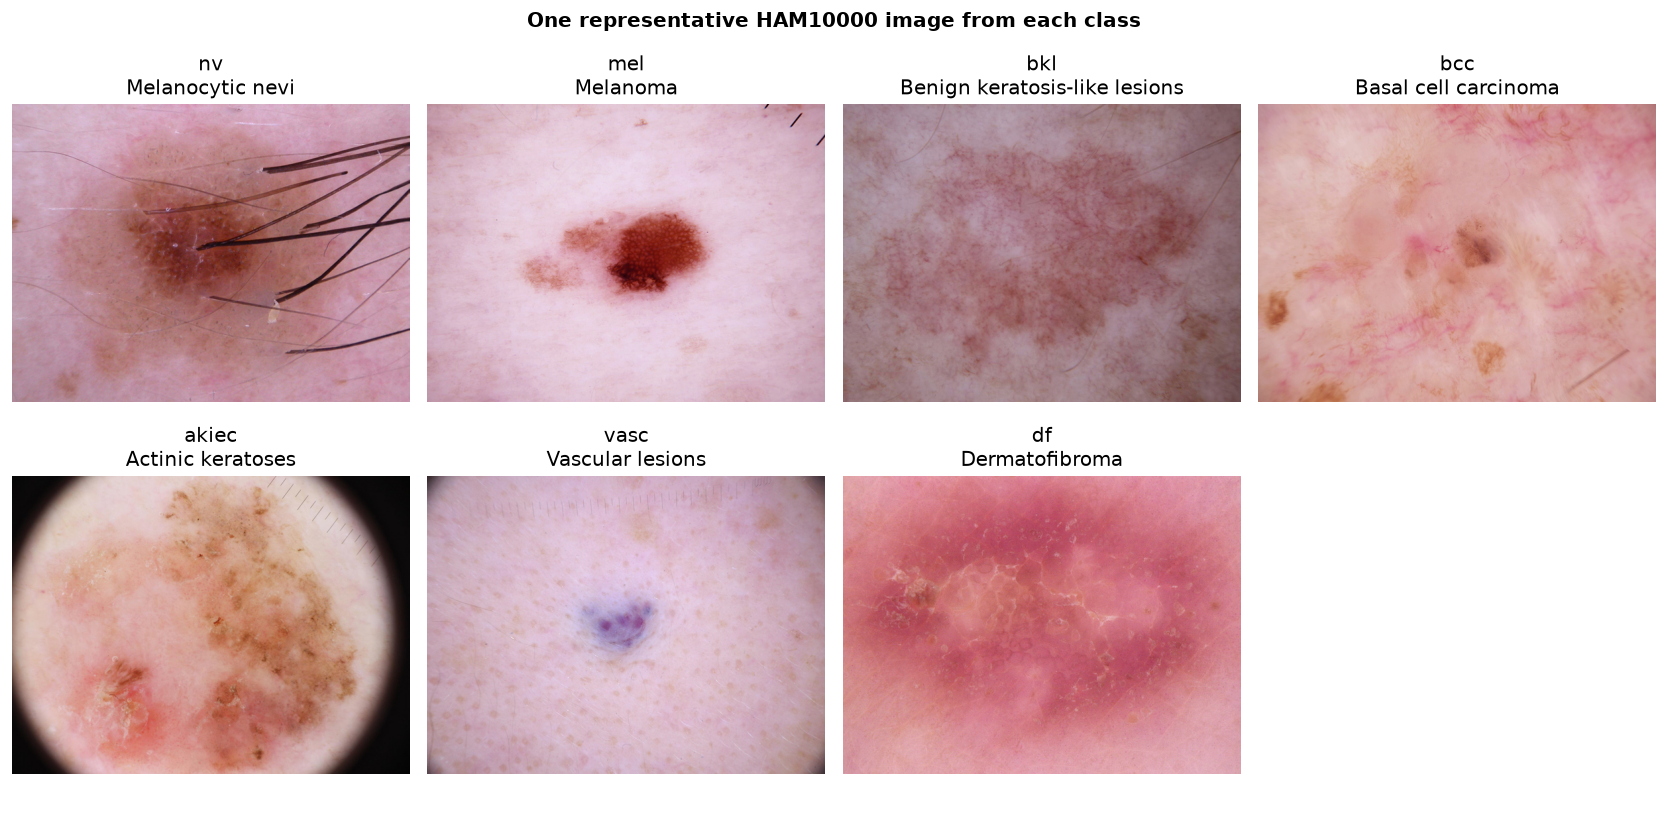

READY: all seven classes displayed


In [15]:
# Checkpoint 5: show one real sample from every class.
sample_rows = []
for class_code in CLASS_ORDER:
    sample_rows.append(metadata[metadata["dx"] == class_code].sample(1, random_state=SEED).iloc[0])

fig, axes = plt.subplots(2, 4, figsize=(14, 7), dpi=120)
for axis, record in zip(axes.flat, sample_rows):
    with Image.open(image_index[record["image_id"]]) as image:
        axis.imshow(image.convert("RGB"))

    axis.set_title(f"{record['dx']}\n{CLASS_NAMES[record['dx']]}")
    axis.axis("off")

for axis in axes.flat[len(sample_rows):]:
    axis.axis("off")

fig.suptitle("One representative HAM10000 image from each class", weight="bold")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "representative_samples.png", bbox_inches="tight")
plt.show()
print("READY: all seven classes displayed")


,class_code,class_name,images,percentage
0,nv,Melanocytic nevi,6705,66.95%
1,mel,Melanoma,1113,11.11%
2,bkl,Benign keratosis-like lesions,1099,10.97%
3,bcc,Basal cell carcinoma,514,5.13%
4,akiec,Actinic keratoses,327,3.27%
5,vasc,Vascular lesions,142,1.42%
6,df,Dermatofibroma,115,1.15%


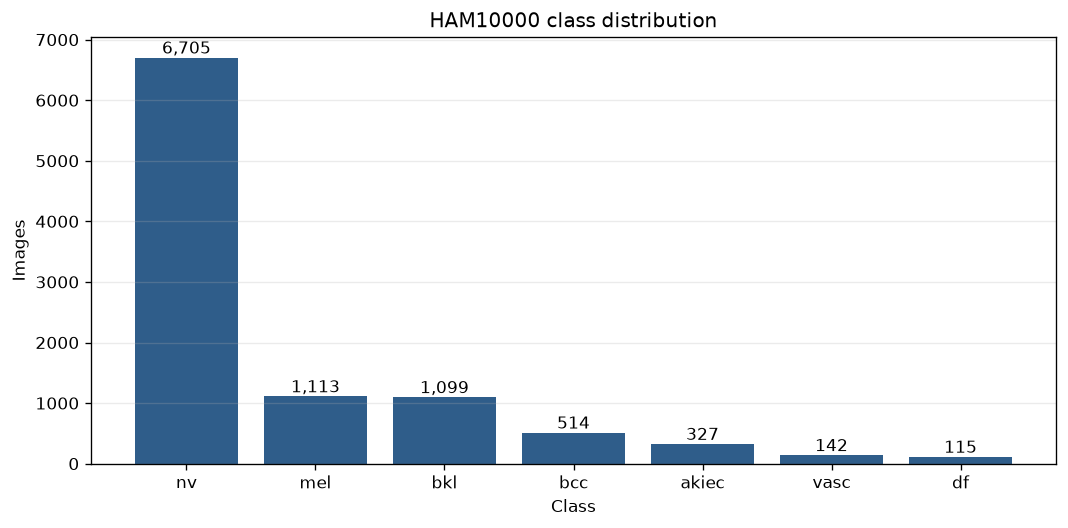

READY: imbalance confirmed; macro-F1 will be the primary validation metric


In [16]:
# Checkpoint 6: inspect class imbalance.
class_counts = metadata["dx"].value_counts().reindex(CLASS_ORDER)
class_table = pd.DataFrame(
    {
        "class_code": class_counts.index,
        "class_name": [CLASS_NAMES[code] for code in class_counts.index],
        "images": class_counts.values,
        "percentage": 100 * class_counts.values / len(metadata),
    }
)

display(class_table.style.format({"percentage": "{:.2f}%"}))

fig, axis = plt.subplots(figsize=(9, 4.5), dpi=120)
bars = axis.bar(class_counts.index, class_counts.values, color="#2F5D8A")
axis.set(title="HAM10000 class distribution", xlabel="Class", ylabel="Images")
axis.grid(axis="y", alpha=0.25)
for bar, count in zip(bars, class_counts.values):
    axis.text(bar.get_x() + bar.get_width() / 2, count, f"{count:,}", ha="center", va="bottom")

fig.tight_layout()
fig.savefig(RESULTS_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()
print("READY: imbalance confirmed; macro-F1 will be the primary validation metric")


## 2. Leakage-aware train/validation/test split

HAM10000 can contain multiple images of the same physical lesion. Therefore, image-level stratification is unsafe. We use `StratifiedGroupKFold` twice:

1. Hold out approximately 20% as test data.
2. Hold out 20% of the remaining 80% as validation data.

This produces approximately 64% training, 16% validation, and 20% test while keeping every `lesion_id` in one partition.


In [17]:
# Checkpoint 7: create or load the fixed Milestone 2 split.
manifest_path = SPLIT_DIR / "all_splits.csv"
if manifest_path.exists() and not FORCE_RECREATE_SPLITS:
    split_manifest = pd.read_csv(manifest_path)
    validate_split_manifest(split_manifest)
    print("Loaded the existing fixed Milestone 2 split.")
else:
    split_manifest = create_milestone2_splits(metadata, outer_seed=SEED, inner_seed=INNER_SPLIT_SEED)
    save_split_manifest(split_manifest, SPLIT_DIR)
    print("Created and saved a new fixed Milestone 2 split.")

expected_image_order = metadata.reset_index(drop=True)["image_id"].astype(str)
manifest_image_order = (split_manifest.sort_values("cache_index")["image_id"].astype(str).reset_index(drop=True))
if not expected_image_order.equals(manifest_image_order):
    raise ValueError("The saved Milestone 2 manifest does not match the current metadata order. Set FORCE_RECREATE_SPLITS=True and rerun this cell.")

summary = split_summary(split_manifest)
counts_by_class = split_class_table(split_manifest)
percentages_by_class = split_class_table(split_manifest, normalize=True)
display(summary.style.format({"image_percentage": "{:.2f}%"}))
display(counts_by_class)
display(percentages_by_class.style.format("{:.2f}%"))

for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    left_lesions = set(split_manifest.loc[split_manifest["split"] == left, "lesion_id"])
    right_lesions = set(split_manifest.loc[split_manifest["split"] == right, "lesion_id"])
    overlap = left_lesions & right_lesions
    assert not overlap, f"Leakage detected between {left} and {right}."

print("READY: grouped split validated; lesion overlap is zero")


Loaded the existing fixed Milestone 2 split.


,split,images,image_percentage,lesions
0,train,6409,63.99%,4781
1,validation,1603,16.01%,1195
2,test,2003,20.00%,1494


dx,akiec,bcc,bkl,df,mel,nv,vasc
split,,,,,,,
train,209,329,703,73,713,4291,91
validation,52,82,176,19,178,1073,23
test,66,103,220,23,222,1341,28


dx,akiec,bcc,bkl,df,mel,nv,vasc
split,,,,,,,
train,3.26%,5.13%,10.97%,1.14%,11.12%,66.95%,1.42%
validation,3.24%,5.12%,10.98%,1.19%,11.10%,66.94%,1.43%
test,3.30%,5.14%,10.98%,1.15%,11.08%,66.95%,1.40%


READY: grouped split validated; lesion overlap is zero


## 3. Training-only preprocessing and PyTorch DataLoaders

Images are resized once to 64×64 and retained as compact `uint8` tensors in memory. This avoids decoding the same JPEG files during every one of the 14 experiments. Normalization statistics, label encoding, and class weights are fitted using the training partition only.


In [18]:
# Checkpoint 8: resize and cache all images once.
image_cache = build_image_cache(
    metadata=metadata,
    image_index=image_index,
    image_size=IMAGE_SIZE,
    show_progress=True,
)
cache_megabytes = image_cache.numel() * image_cache.element_size() / (1024 ** 2)
assert image_cache.shape == (len(metadata), 3, IMAGE_SIZE, IMAGE_SIZE)
assert image_cache.dtype == torch.uint8
print(f"READY: cache shape {tuple(image_cache.shape)}, {cache_megabytes:.1f} MiB")


Caching resized images:   0%|          | 0/10015 [00:00<?, ?it/s]

READY: cache shape (10015, 3, 64, 64), 117.4 MiB


In [20]:
# Checkpoint 9: fit preprocessing parameters on training data only.
train_frame = split_manifest[split_manifest["split"] == "train"].copy()
train_cache_indices = train_frame["cache_index"].to_numpy(copy=True)
channel_mean, channel_std = compute_channel_stats(image_cache, train_cache_indices)

label_to_index = fit_label_mapping(train_frame["dx"])
index_to_label = {index: label for label, index in label_to_index.items()}
encoded_train_labels = train_frame["dx"].map(label_to_index).to_numpy(copy=True)
class_weights = compute_class_weights(encoded_train_labels, len(label_to_index))

preprocessing_table = pd.DataFrame(
    {
        "class_code": [index_to_label[index] for index in range(len(index_to_label))],
        "encoded_label": list(range(len(index_to_label))),
        "training_count": np.bincount(encoded_train_labels, minlength=len(index_to_label)),
        "class_weight": class_weights.numpy(),
    }
)

print(f"Training-only RGB mean: {channel_mean.tolist()}")
print(f"Training-only RGB std:  {channel_std.tolist()}")
display(preprocessing_table.style.format({"class_weight": "{:.4f}"}))
print("READY: normalization, label encoding, and class weights fitted without validation/test data")


Training-only RGB mean: [0.762795090675354, 0.5452789068222046, 0.5697905421257019]
Training-only RGB std:  [0.1402204930782318, 0.15203404426574707, 0.1686755269765854]


,class_code,encoded_label,training_count,class_weight
0,akiec,0,209,4.3807
1,bcc,1,329,2.7829
2,bkl,2,703,1.3024
3,df,3,73,12.5421
4,mel,4,713,1.2841
5,nv,5,4291,0.2134
6,vasc,6,91,10.0612


READY: normalization, label encoding, and class weights fitted without validation/test data


In [22]:
# Checkpoint 10: create DataLoaders and inspect one batch.
preview_loaders = make_dataloaders(
    split_manifest=split_manifest,
    image_cache=image_cache,
    label_to_index=label_to_index,
    mean=channel_mean,
    std=channel_std,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
    pin_memory=DEVICE.type == "cuda",
    include_test=False,
)
batch_images, batch_labels = next(iter(preview_loaders["train"]))
assert batch_images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert batch_images.dtype == torch.float32
assert batch_labels.dtype == torch.int64
print(f"Training batches:   {len(preview_loaders['train']):,}")
print(f"Validation batches: {len(preview_loaders['validation']):,}")
print(f"Batch image shape:  {tuple(batch_images.shape)}")
print(f"Batch label shape:  {tuple(batch_labels.shape)}")
print("READY: PyTorch DataLoaders validated")
del preview_loaders, batch_images, batch_labels


Training batches:   51
Validation batches: 13
Batch image shape:  (128, 3, 64, 64)
Batch label shape:  (128,)
READY: PyTorch DataLoaders validated


## 4. Flexible MLP implementation

The reusable `MLPClassifier` receives any hidden-layer list.

- **Shallow:** 12,288 → 512 → 128 → 7
- **Deep:** 12,288 → 512 → 256 → 128 → 64 → 32 → 7
- **Hidden block:** Linear → Batch normalization → ReLU → Dropout
- **Output:** Seven raw logits; softmax is excluded because the losses expect logits.

ReLU is computationally efficient and avoids the strong saturation associated with sigmoid and tanh. The two networks have similar parameter counts, making the depth comparison more meaningful.


In [24]:
# Checkpoint 11: instantiate both network depths and verify output shape.
shallow_preview = MLPClassifier(
    INPUT_DIM, SHALLOW_HIDDEN_DIMS, len(label_to_index),
    activation=ACTIVATION, dropout=DROPOUT, batch_norm=True,
)
deep_preview = MLPClassifier(
    INPUT_DIM, DEEP_HIDDEN_DIMS, len(label_to_index),
    activation=ACTIVATION, dropout=DROPOUT, batch_norm=True,
)
dummy = torch.zeros(4, 3, IMAGE_SIZE, IMAGE_SIZE)
shallow_preview.eval()
deep_preview.eval()
assert shallow_preview(dummy).shape == (4, len(label_to_index))
assert deep_preview(dummy).shape == (4, len(label_to_index))
architecture_table = pd.DataFrame(
    [
        {"network": "Shallow", "hidden_layers": str(SHALLOW_HIDDEN_DIMS), "trainable_parameters": count_trainable_parameters(shallow_preview)},
        {"network": "Deep", "hidden_layers": str(DEEP_HIDDEN_DIMS), "trainable_parameters": count_trainable_parameters(deep_preview)},
    ]
)
display(architecture_table.style.format({"trainable_parameters": "{:,}"}))
print("READY: both architectures produce seven raw logits")
del shallow_preview, deep_preview, dummy


,network,hidden_layers,trainable_parameters
0,Shallow,"[512, 128]","6,359,815"
1,Deep,"[512, 256, 128, 64, 32]","6,468,743"


READY: both architectures produce seven raw logits


## 5. Experiment definitions

Three losses are compared:

1. Class-weighted cross-entropy
2. Class-weighted cross-entropy with label smoothing = 0.10
3. Class-weighted focal loss with γ = 2

The optimizers are SGD with momentum 0.9, RMSprop, and Adam. The first comparison uses the same learning rate (`0.001`) to isolate the effect of loss and optimizer. Every run resets seed 471, so weight initialization and batch order remain controlled.

Macro-F1 is the primary validation metric because the class distribution is severely imbalanced. The test partition remains unused until Section 9.


In [25]:
# Checkpoint 12: define the controlled experiment space.
LOSS_NAMES = ["cross_entropy", "label_smoothing", "focal"]
OPTIMIZER_NAMES = ["sgd", "rmsprop", "adam"]

def run_training_configuration(hidden_dims, loss_name, optimizer_name, learning_rate, max_epochs, verbose=True):
    return train_configuration(
        split_manifest=split_manifest,
        image_cache=image_cache,
        label_to_index=label_to_index,
        mean=channel_mean,
        std=channel_std,
        class_weights=class_weights,
        hidden_dims=hidden_dims,
        input_dim=INPUT_DIM,
        loss_name=loss_name,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
        weight_decay=WEIGHT_DECAY,
        dropout=DROPOUT,
        activation=ACTIVATION,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        seed=SEED,
        device=DEVICE,
        max_epochs=max_epochs,
        patience=EARLY_STOPPING_PATIENCE,
        label_smoothing=LABEL_SMOOTHING,
        focal_gamma=FOCAL_GAMMA,
        verbose=verbose,
    )

print(f"READY: {len(LOSS_NAMES) * len(OPTIMIZER_NAMES)} grid runs configured")


READY: 9 grid runs configured


## 6. Complete 3 × 3 loss-optimizer comparison

This is the first long-running cell. It saves one history CSV after every completed run and updates the result table incrementally. If execution stops, rerun the cell to continue completed configurations instead of starting over.


In [30]:
# Checkpoint 13: run all nine shallow-network combinations.
grid_results_path = RESULTS_DIR / "optimizer_loss_results.csv"
if FORCE_RERUN_EXPERIMENTS and grid_results_path.exists():
    grid_results_path.unlink()
if grid_results_path.exists():
    grid_results = pd.read_csv(grid_results_path)
else:
    grid_results = pd.DataFrame()

for loss_name in LOSS_NAMES:
    for optimizer_name in OPTIMIZER_NAMES:
        already_done = False
        if not grid_results.empty:
            mask = ((grid_results["loss"] == loss_name) & (grid_results["optimizer"] == optimizer_name) & np.isclose(grid_results["learning_rate"], BASE_LEARNING_RATE))
            already_done = bool(mask.any())
        if already_done:
            print(f"SKIP: {loss_name} + {optimizer_name} already completed")
            continue

        print("\n" + "=" * 72)
        print(f"RUN: loss={loss_name}, optimizer={optimizer_name}, lr={BASE_LEARNING_RATE:g}")
        started = time.perf_counter()
        artifacts = run_training_configuration(
            SHALLOW_HIDDEN_DIMS,
            loss_name,
            optimizer_name,
            BASE_LEARNING_RATE,
            GRID_MAX_EPOCHS,
        )
        elapsed = time.perf_counter() - started
        history_path = HISTORY_DIR / f"grid_{loss_name}_{optimizer_name}.csv"
        artifacts.fit.history.to_csv(history_path, index=False)
        best_history_row = artifacts.fit.history.loc[artifacts.fit.history["epoch"] == artifacts.fit.best_epoch].iloc[0]
        row = {
            "loss": loss_name,
            "optimizer": optimizer_name,
            "learning_rate": BASE_LEARNING_RATE,
            "best_epoch": artifacts.fit.best_epoch,
            "validation_loss": artifacts.fit.best_validation_loss,
            "validation_accuracy": best_history_row["validation_accuracy"],
            "validation_macro_f1": artifacts.fit.best_validation_macro_f1,
            "trainable_parameters": artifacts.parameter_count,
            "elapsed_seconds": elapsed,
        }
        grid_results = pd.concat([grid_results, pd.DataFrame([row])], ignore_index=True)
        grid_results.to_csv(grid_results_path, index=False)
        del artifacts
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

grid_results = grid_results.drop_duplicates(["loss", "optimizer"], keep="last")
if len(grid_results) != 9:
    raise RuntimeError(f"Expected 9 completed grid runs; found {len(grid_results)}.")
print("READY: all nine loss–optimizer runs completed")



RUN: loss=cross_entropy, optimizer=sgd, lr=0.001
Epoch 01/20 | train loss 1.8211, F1 0.1629 | val loss 1.6531, F1 0.2321
Epoch 02/20 | train loss 1.6978, F1 0.2448 | val loss 1.5053, F1 0.2811
Epoch 03/20 | train loss 1.6497, F1 0.2524 | val loss 1.4012, F1 0.2745
Epoch 04/20 | train loss 1.5907, F1 0.2783 | val loss 1.4573, F1 0.2764
Epoch 05/20 | train loss 1.5443, F1 0.2784 | val loss 1.4657, F1 0.2791
Epoch 06/20 | train loss 1.5405, F1 0.2885 | val loss 1.4210, F1 0.3006
Epoch 07/20 | train loss 1.5009, F1 0.2923 | val loss 1.3484, F1 0.3099
Epoch 08/20 | train loss 1.4940, F1 0.3007 | val loss 1.3699, F1 0.3050
Epoch 09/20 | train loss 1.4489, F1 0.3007 | val loss 1.3522, F1 0.3249
Epoch 10/20 | train loss 1.4220, F1 0.3098 | val loss 1.2921, F1 0.3180
Epoch 11/20 | train loss 1.4066, F1 0.3140 | val loss 1.3293, F1 0.3200
Epoch 12/20 | train loss 1.3973, F1 0.3134 | val loss 1.2115, F1 0.3220
Epoch 13/20 | train loss 1.3814, F1 0.3181 | val loss 1.2352, F1 0.3218
Epoch 14/20 | 

In [31]:
# Checkpoint 14: compare the nine runs and choose by validation macro-F1.
grid_ranked = grid_results.sort_values(["validation_macro_f1", "validation_loss"],ascending=[False, True]).reset_index(drop=True)
display(grid_ranked.style.format(
    {
        "learning_rate": "{:.4g}",
        "validation_loss": "{:.4f}",
        "validation_accuracy": "{:.4f}",
        "validation_macro_f1": "{:.4f}",
        "trainable_parameters": "{:,}",
        "elapsed_seconds": "{:.1f}"
    }).highlight_max(subset=["validation_macro_f1"], color="#c6efce")
)

pivot = grid_results.pivot(index="loss", columns="optimizer", values="validation_macro_f1")
display(pivot.style.format("{:.4f}").highlight_max(axis=None, color="#c6efce"))

best_loss = str(grid_ranked.loc[0, "loss"])
best_optimizer = str(grid_ranked.loc[0, "optimizer"])
print(f"SELECTED: loss={best_loss}, optimizer={best_optimizer}")
print("Selection used validation macro-F1 only; test data remains untouched.")


,loss,optimizer,learning_rate,best_epoch,validation_loss,validation_accuracy,validation_macro_f1,trainable_parameters,elapsed_seconds
0,cross_entropy,adam,0.001,19,1.0725,0.5976,0.3892,"6,359,815",33.3
1,cross_entropy,sgd,0.001,19,1.0969,0.5739,0.3739,"6,359,815",33.1
2,focal,rmsprop,0.001,10,0.9395,0.5820,0.3737,"6,359,815",24.7
3,focal,sgd,0.001,19,0.8497,0.5764,0.3713,"6,359,815",32.9
4,focal,adam,0.001,10,0.8681,0.5614,0.3625,"6,359,815",24.9
5,cross_entropy,rmsprop,0.001,10,1.2094,0.5521,0.3483,"6,359,815",24.8
6,label_smoothing,rmsprop,0.001,10,4.2917,0.4205,0.3193,"6,359,815",25.1
7,label_smoothing,sgd,0.001,19,4.2543,0.3930,0.3076,"6,359,815",33.7
8,label_smoothing,adam,0.001,3,4.3171,0.2776,0.2608,"6,359,815",13.5


optimizer,adam,rmsprop,sgd
loss,,,
cross_entropy,0.3892,0.3483,0.3739
focal,0.3625,0.3737,0.3713
label_smoothing,0.2608,0.3193,0.3076


SELECTED: loss=cross_entropy, optimizer=adam
Selection used validation macro-F1 only; test data remains untouched.


## 7. Four-learning-rate comparison

The winning loss-optimizer pair is now evaluated at `0.0001`, `0.0003`, `0.001`, and `0.003`. Each run saves its own checkpoint so the best shallow network can be restored without retraining.


In [32]:
# Checkpoint 15: run the four learning-rate experiments.
lr_results_path = RESULTS_DIR / "learning_rate_results.csv"
if FORCE_RERUN_EXPERIMENTS and lr_results_path.exists():
    lr_results_path.unlink()
if lr_results_path.exists():
    lr_results = pd.read_csv(lr_results_path)
else:
    lr_results = pd.DataFrame()

for learning_rate in LEARNING_RATES:
    tag = f"{learning_rate:.0e}".replace("-", "m").replace("+", "p")
    checkpoint_path = CHECKPOINT_DIR / f"shallow_lr_{tag}.pt"
    already_done = False
    if not lr_results.empty:
        mask = ((lr_results["loss"] == best_loss) & (lr_results["optimizer"] == best_optimizer) & np.isclose(lr_results["learning_rate"], learning_rate))
        already_done = bool(mask.any()) and checkpoint_path.exists()
    if already_done:
        print(f"SKIP: learning rate {learning_rate:g} already completed")
        continue

    print("\n" + "=" * 72)
    print(f"RUN: loss={best_loss}, optimizer={best_optimizer}, lr={learning_rate:g}")
    started = time.perf_counter()
    artifacts = run_training_configuration(SHALLOW_HIDDEN_DIMS, best_loss, best_optimizer, learning_rate,LR_MAX_EPOCHS)
    elapsed = time.perf_counter() - started
    history_path = HISTORY_DIR / f"shallow_lr_{tag}.csv"
    artifacts.fit.history.to_csv(history_path, index=False)
    best_history_row = artifacts.fit.history.loc[artifacts.fit.history["epoch"] == artifacts.fit.best_epoch].iloc[0]
    checkpoint_metadata = {
        "network": "shallow",
        "hidden_dims": SHALLOW_HIDDEN_DIMS,
        "loss": best_loss,
        "optimizer": best_optimizer,
        "learning_rate": learning_rate,
        "input_dim": INPUT_DIM,
        "num_classes": len(label_to_index),
        "dropout": DROPOUT,
        "weight_decay": WEIGHT_DECAY,
    }
    save_checkpoint(checkpoint_path, artifacts.model, artifacts.fit, checkpoint_metadata)
    row = {
        "loss": best_loss,
        "optimizer": best_optimizer,
        "learning_rate": learning_rate,
        "best_epoch": artifacts.fit.best_epoch,
        "validation_loss": artifacts.fit.best_validation_loss,
        "validation_accuracy": best_history_row["validation_accuracy"],
        "validation_macro_f1": artifacts.fit.best_validation_macro_f1,
        "elapsed_seconds": elapsed,
        "checkpoint": str(checkpoint_path.relative_to(PROJECT_ROOT)),
    }
    if not lr_results.empty:
        duplicate = ((lr_results["loss"] == best_loss) & (lr_results["optimizer"] == best_optimizer) & np.isclose(lr_results["learning_rate"], learning_rate))
        lr_results = lr_results.loc[~duplicate]
    lr_results = pd.concat([lr_results, pd.DataFrame([row])], ignore_index=True)
    lr_results.to_csv(lr_results_path, index=False)
    del artifacts
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if len(lr_results) != 4:
    raise RuntimeError(f"Expected 4 completed learning-rate runs; found {len(lr_results)}.")
print("READY: all four learning-rate runs completed")



RUN: loss=cross_entropy, optimizer=adam, lr=0.0001
Epoch 01/20 | train loss 1.8179, F1 0.1608 | val loss 1.8182, F1 0.2368
Epoch 02/20 | train loss 1.7075, F1 0.2289 | val loss 1.6766, F1 0.2773
Epoch 03/20 | train loss 1.6575, F1 0.2487 | val loss 1.5770, F1 0.2857
Epoch 04/20 | train loss 1.5868, F1 0.2728 | val loss 1.5581, F1 0.2926
Epoch 05/20 | train loss 1.5591, F1 0.2717 | val loss 1.5404, F1 0.2953
Epoch 06/20 | train loss 1.5241, F1 0.2864 | val loss 1.4748, F1 0.3180
Epoch 07/20 | train loss 1.5086, F1 0.2975 | val loss 1.3932, F1 0.3148
Epoch 08/20 | train loss 1.4855, F1 0.2920 | val loss 1.3631, F1 0.3107
Epoch 09/20 | train loss 1.4396, F1 0.3092 | val loss 1.3484, F1 0.3220
Epoch 10/20 | train loss 1.4211, F1 0.3107 | val loss 1.3138, F1 0.3251
Epoch 11/20 | train loss 1.3895, F1 0.3245 | val loss 1.3713, F1 0.3338
Epoch 12/20 | train loss 1.3821, F1 0.3320 | val loss 1.2693, F1 0.3367
Epoch 13/20 | train loss 1.3731, F1 0.3227 | val loss 1.2177, F1 0.3332
Epoch 14/20 

In [33]:
# Checkpoint 16: rank learning rates and restore the optimal shallow model.
lr_ranked = lr_results.sort_values(["validation_macro_f1", "validation_loss"], ascending=[False, True]).reset_index(drop=True)
display(lr_ranked.style.format(
    {
        "learning_rate": "{:.4g}",
        "validation_loss": "{:.4f}",
        "validation_accuracy": "{:.4f}",
        "validation_macro_f1": "{:.4f}",
        "elapsed_seconds": "{:.1f}",
    }).highlight_max(subset=["validation_macro_f1"], color="#c6efce")
)

best_learning_rate = float(lr_ranked.loc[0, "learning_rate"])
selected_checkpoint = PROJECT_ROOT / str(lr_ranked.loc[0, "checkpoint"])
best_shallow_path = CHECKPOINT_DIR / "best_shallow.pt"
shutil.copy2(selected_checkpoint, best_shallow_path)

shallow_model = MLPClassifier(INPUT_DIM, SHALLOW_HIDDEN_DIMS, len(label_to_index), activation=ACTIVATION, dropout=DROPOUT, batch_norm=True)
shallow_checkpoint = load_checkpoint(best_shallow_path, shallow_model, map_location=DEVICE)
shallow_model.to(DEVICE)
shallow_history = pd.DataFrame(shallow_checkpoint["history"])
print(f"SELECTED: learning rate={best_learning_rate:g}")
print(f"Best shallow validation macro-F1={shallow_checkpoint['best_validation_macro_f1']:.4f}")


,loss,optimizer,learning_rate,best_epoch,validation_loss,validation_accuracy,validation_macro_f1,elapsed_seconds,checkpoint
0,cross_entropy,adam,0.001,19,1.0725,0.5976,0.3892,33.6,results/milestone_02/checkpoints/shallow_lr_1em03.pt
1,cross_entropy,adam,0.0001,19,1.1159,0.5683,0.3830,34.1,results/milestone_02/checkpoints/shallow_lr_1em04.pt
2,cross_entropy,adam,0.003,10,1.1776,0.5652,0.3639,25.3,results/milestone_02/checkpoints/shallow_lr_3em03.pt
3,cross_entropy,adam,0.0003,9,1.2311,0.5034,0.3461,23.3,results/milestone_02/checkpoints/shallow_lr_3em04.pt


SELECTED: learning rate=0.001
Best shallow validation macro-F1=0.3892


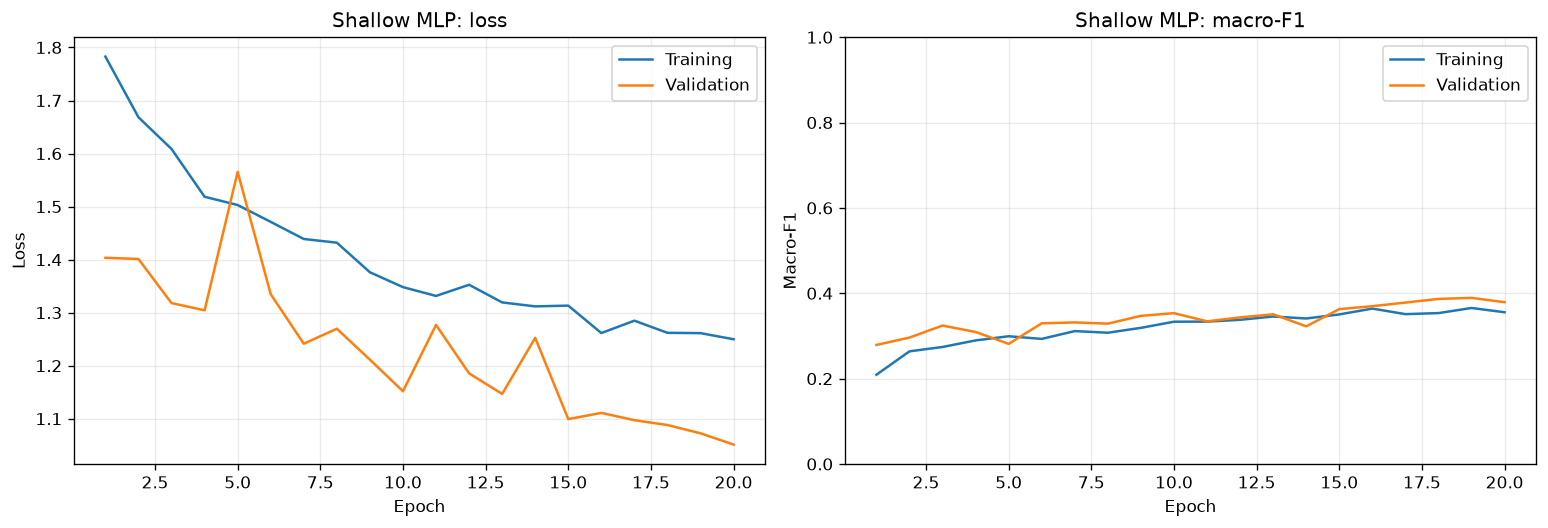

READY: shallow training curves generated


In [36]:
# Checkpoint 17: plot the optimal shallow model's required curves.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=120)
axes[0].plot(shallow_history["epoch"], shallow_history["train_loss"], label="Training")
axes[0].plot(shallow_history["epoch"], shallow_history["validation_loss"], label="Validation")
axes[0].set(title="Shallow MLP: loss", xlabel="Epoch", ylabel="Loss")
axes[1].plot(shallow_history["epoch"], shallow_history["train_macro_f1"], label="Training")
axes[1].plot(shallow_history["epoch"], shallow_history["validation_macro_f1"], label="Validation")
axes[1].set(title="Shallow MLP: macro-F1", xlabel="Epoch", ylabel="Macro-F1", ylim=(0, 1))
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "shallow_training_curves.png", bbox_inches="tight")
plt.show()
print("READY: shallow training curves generated")


## 8. Five-hidden-layer MLP

The deeper MLP uses the loss, optimizer, learning rate, augmentation, and regularization selected for the shallow model. This follows the required experimental sequence and prevents tuning the deeper model on the test set.


In [37]:
# Checkpoint 18: train or restore the five-hidden-layer MLP.
deep_checkpoint_path = CHECKPOINT_DIR / "best_deep.pt"
if deep_checkpoint_path.exists() and not FORCE_RERUN_EXPERIMENTS:
    deep_model = MLPClassifier(INPUT_DIM, DEEP_HIDDEN_DIMS, len(label_to_index), activation=ACTIVATION, dropout=DROPOUT, batch_norm=True)
    deep_checkpoint = load_checkpoint(deep_checkpoint_path, deep_model, map_location=DEVICE)
    deep_model.to(DEVICE)
    deep_history = pd.DataFrame(deep_checkpoint["history"])
    print("Loaded existing deep checkpoint.")
else:
    deep_artifacts = run_training_configuration(DEEP_HIDDEN_DIMS, best_loss, best_optimizer, best_learning_rate, DEEP_MAX_EPOCHS)
    deep_model = deep_artifacts.model
    deep_history = deep_artifacts.fit.history
    deep_history.to_csv(HISTORY_DIR / "deep_optimal.csv", index=False)
    deep_metadata = {
        "network": "deep",
        "hidden_dims": DEEP_HIDDEN_DIMS,
        "loss": best_loss,
        "optimizer": best_optimizer,
        "learning_rate": best_learning_rate,
        "input_dim": INPUT_DIM,
        "num_classes": len(label_to_index),
        "dropout": DROPOUT,
        "weight_decay": WEIGHT_DECAY,
    }
    save_checkpoint(deep_checkpoint_path, deep_model, deep_artifacts.fit, deep_metadata)
    deep_checkpoint = load_checkpoint(deep_checkpoint_path, deep_model, map_location=DEVICE)

print(f"READY: deep best validation macro-F1={deep_checkpoint['best_validation_macro_f1']:.4f}")


Epoch 01/25 | train loss 1.9476, F1 0.1161 | val loss 1.7148, F1 0.1908
Epoch 02/25 | train loss 1.8557, F1 0.1924 | val loss 1.6054, F1 0.2506
Epoch 03/25 | train loss 1.8061, F1 0.2173 | val loss 1.5611, F1 0.2403
Epoch 04/25 | train loss 1.7672, F1 0.2366 | val loss 1.5000, F1 0.2688
Epoch 05/25 | train loss 1.7238, F1 0.2328 | val loss 1.5115, F1 0.2395
Epoch 06/25 | train loss 1.7097, F1 0.2392 | val loss 1.5624, F1 0.2444
Epoch 07/25 | train loss 1.7080, F1 0.2498 | val loss 1.4409, F1 0.2662
Epoch 08/25 | train loss 1.6778, F1 0.2451 | val loss 1.4424, F1 0.2755
Epoch 09/25 | train loss 1.6562, F1 0.2625 | val loss 1.3571, F1 0.2884
Epoch 10/25 | train loss 1.6173, F1 0.2739 | val loss 1.3054, F1 0.3344
Epoch 11/25 | train loss 1.5960, F1 0.2688 | val loss 1.4507, F1 0.2865
Epoch 12/25 | train loss 1.5799, F1 0.2691 | val loss 1.2644, F1 0.3051
Epoch 13/25 | train loss 1.5527, F1 0.2742 | val loss 1.3075, F1 0.3221
Epoch 14/25 | train loss 1.5292, F1 0.2849 | val loss 1.4015, F1

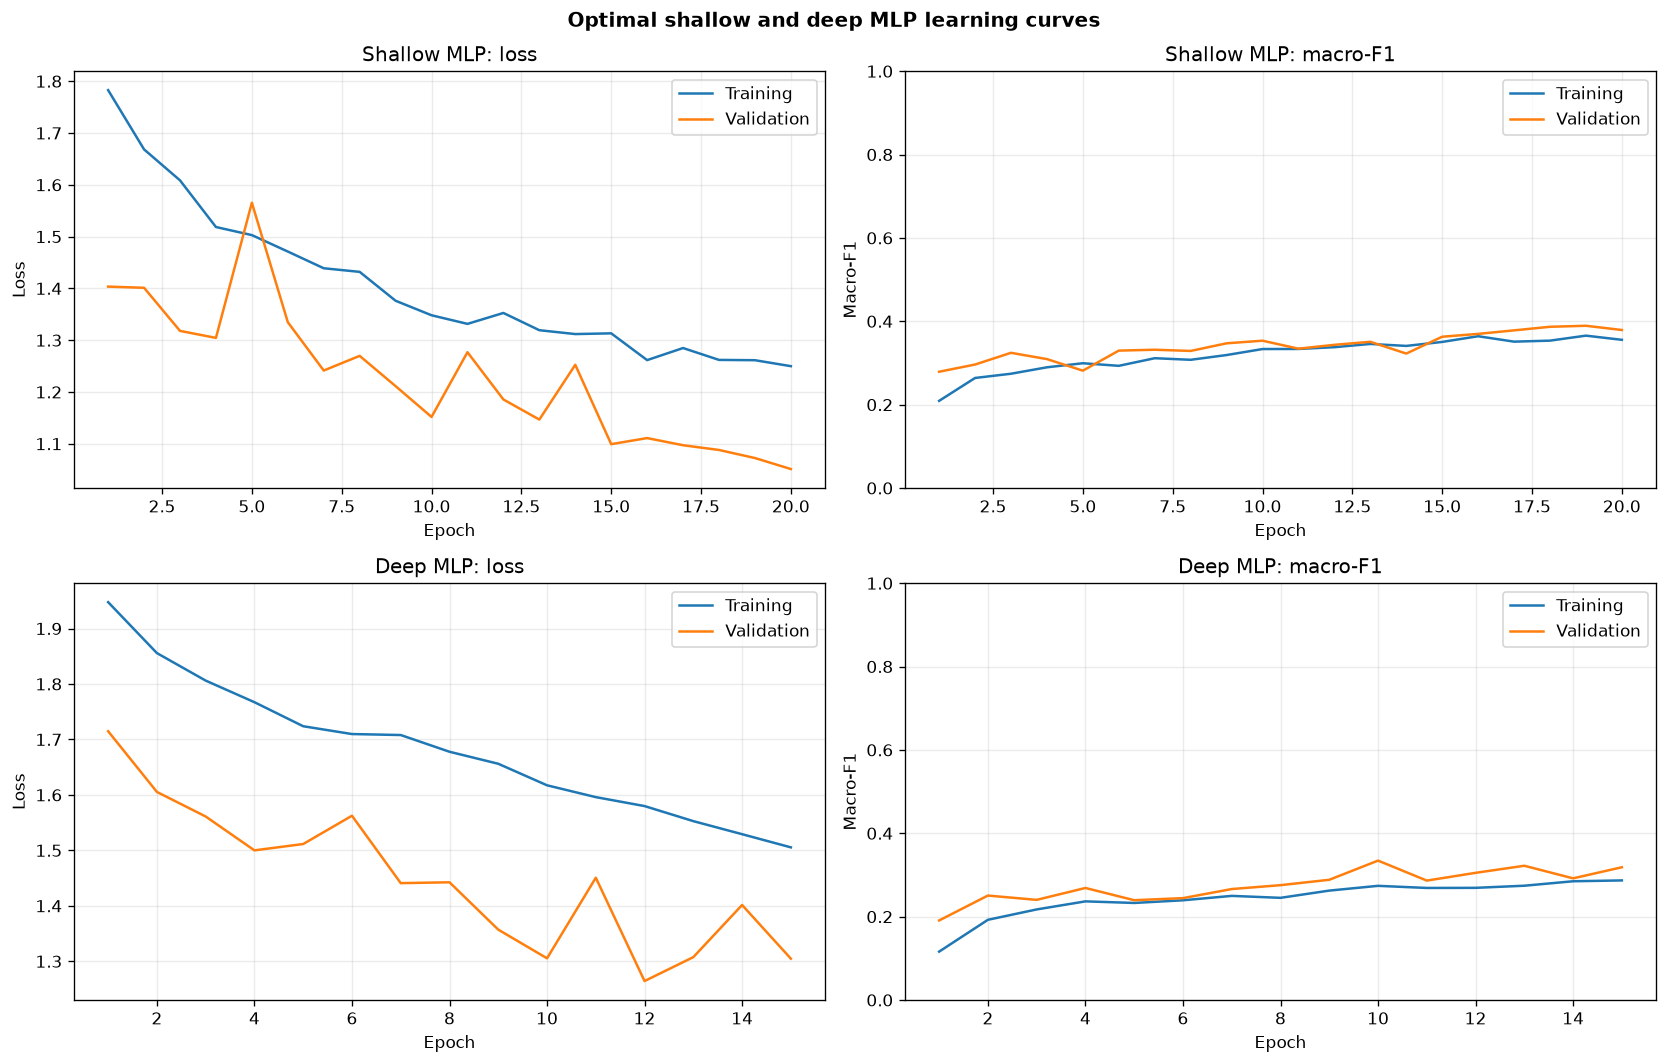

READY: all required learning curves generated


In [39]:
# Checkpoint 19: produce all required shallow/deep curves in one figure.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=120)
histories = [("Shallow MLP", shallow_history), ("Deep MLP", deep_history)]
for row, (name, history) in enumerate(histories):
    axes[row, 0].plot(history["epoch"], history["train_loss"], label="Training")
    axes[row, 0].plot(history["epoch"], history["validation_loss"], label="Validation")
    axes[row, 0].set(title=f"{name}: loss", xlabel="Epoch", ylabel="Loss")
    axes[row, 1].plot(history["epoch"], history["train_macro_f1"], label="Training")
    axes[row, 1].plot(history["epoch"], history["validation_macro_f1"], label="Validation")
    axes[row, 1].set(title=f"{name}: macro-F1", xlabel="Epoch", ylabel="Macro-F1", ylim=(0, 1))
    for axis in axes[row]:
        axis.grid(alpha=0.25)
        axis.legend()
fig.suptitle("Optimal shallow and deep MLP learning curves", weight="bold")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_curves.png", bbox_inches="tight")
plt.show()
print("READY: all required learning curves generated")


## 9. Final test comparison

Stop and verify that Sections 6–8 are complete before running the next cell. This is the first point at which the test partition is evaluated. Both selected networks are evaluated on exactly the same untouched examples.


In [40]:
# Checkpoint 20: one-time final evaluation of shallow and deep networks.
final_loaders = make_dataloaders(
    split_manifest=split_manifest,
    image_cache=image_cache,
    label_to_index=label_to_index,
    mean=channel_mean,
    std=channel_std,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
    pin_memory=DEVICE.type == "cuda",
    include_test=True,
)
test_loader = final_loaders["test"]
final_criterion = build_loss(best_loss, class_weights.to(DEVICE), label_smoothing=LABEL_SMOOTHING, focal_gamma=FOCAL_GAMMA).to(DEVICE)

final_metrics = {}
final_predictions = {}
test_rows = []
for network_name, model in (("Shallow MLP", shallow_model), ("Deep MLP", deep_model)):
    metrics = evaluate_model(model, test_loader, final_criterion, DEVICE)
    final_metrics[network_name] = metrics
    final_predictions[network_name] = metrics["predictions"]
    test_rows.append(
        {
            "network": network_name,
            "hidden_layers": 2 if network_name == "Shallow MLP" else 5,
            "trainable_parameters": count_trainable_parameters(model),
            "test_loss": metrics["loss"],
            "test_accuracy": metrics["accuracy"],
            "test_macro_f1": metrics["macro_f1"],
        }
    )

test_results = pd.DataFrame(test_rows).sort_values("test_macro_f1", ascending=False)
test_results.to_csv(RESULTS_DIR / "test_comparison.csv", index=False)
display(test_results.style.format(
    {
        "trainable_parameters": "{:,}",
        "test_loss": "{:.4f}",
        "test_accuracy": "{:.4f}",
        "test_macro_f1": "{:.4f}",
    }).highlight_max(subset=["test_macro_f1"], color="#c6efce")
)
print("READY: final test comparison completed")


,network,hidden_layers,trainable_parameters,test_loss,test_accuracy,test_macro_f1
0,Shallow MLP,2,"6,359,815",1.0424,0.5861,0.3890
1,Deep MLP,5,"6,468,743",1.2918,0.5117,0.3015


READY: final test comparison completed


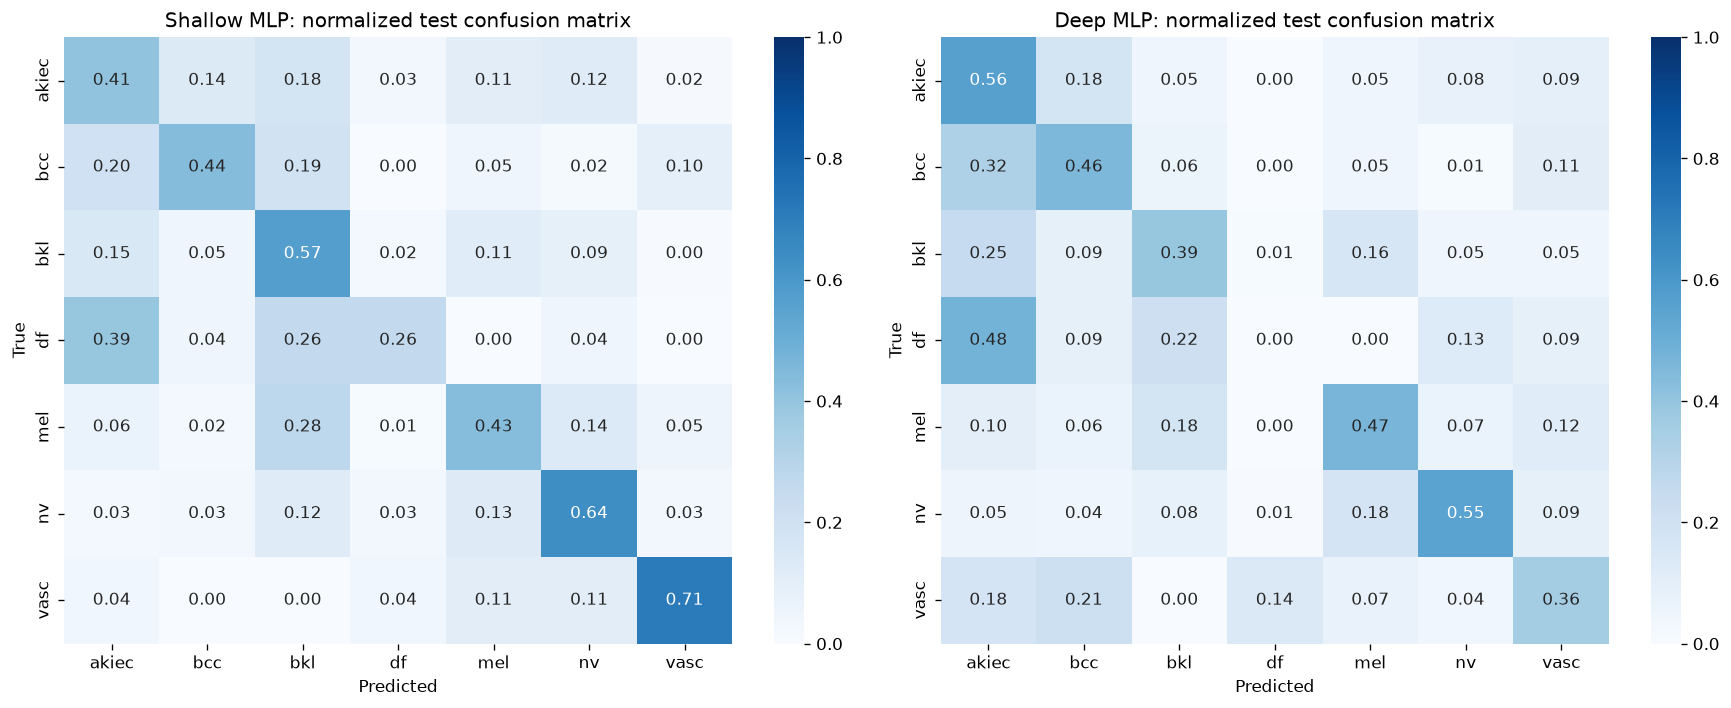

READY: confusion matrices and predictions saved


In [41]:
# Checkpoint 21: confusion matrices and per-image prediction export.
label_order = list(range(len(index_to_label)))
class_codes = [index_to_label[index] for index in label_order]
true_targets = final_metrics["Shallow MLP"]["targets"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=120)
for axis, network_name in zip(axes, ("Shallow MLP", "Deep MLP")):
    matrix = confusion_matrix(
        true_targets,
        final_predictions[network_name],
        labels=label_order,
        normalize="true",
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=class_codes,
        yticklabels=class_codes,
        ax=axis,
    )
    axis.set(title=f"{network_name}: normalized test confusion matrix", xlabel="Predicted", ylabel="True")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()

test_frame = split_manifest[split_manifest["split"] == "test"].reset_index(drop=True)
prediction_export = test_frame[["image_id", "lesion_id", "dx"]].copy()
prediction_export["shallow_prediction"] = [index_to_label[int(x)] for x in final_predictions["Shallow MLP"]]
prediction_export["deep_prediction"] = [index_to_label[int(x)] for x in final_predictions["Deep MLP"]]
prediction_export.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)
print("READY: confusion matrices and predictions saved")


## 10. Conclusion and limitations

The following cell generates the direct architecture comparison from the final test table. The result is descriptive, not clinical: HAM10000 is imbalanced, contains acquisition artifacts, and does not establish performance on external hospitals or patient populations. An MLP also discards explicit two-dimensional spatial structure when it flattens the image. A CNN is expected to be a more suitable image model in a later milestone.


In [42]:
# Checkpoint 22: generate the final evidence-based conclusion and verify saved outputs.
winner = test_results.iloc[0]
runner_up = test_results.iloc[1]
difference = winner["test_macro_f1"] - runner_up["test_macro_f1"]
print(
    f"The {winner['network']} achieved the higher test macro-F1 "
    f"({winner['test_macro_f1']:.4f} vs. {runner_up['test_macro_f1']:.4f}), "
    f"a difference of {difference:.4f}."
)
print(
    f"Its test accuracy was {winner['test_accuracy']:.4f}. "
    "Macro-F1 remains the primary result because HAM10000 is strongly imbalanced."
)

required_outputs = [
    RESULTS_DIR / "optimizer_loss_results.csv",
    RESULTS_DIR / "learning_rate_results.csv",
    RESULTS_DIR / "training_curves.png",
    RESULTS_DIR / "test_comparison.csv",
    RESULTS_DIR / "confusion_matrices.png",
]
missing_outputs = [path.name for path in required_outputs if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(f"Required result files are missing: {missing_outputs}")
print("READY: Milestone 2 experiment workflow is complete")
print("Before submission: save this notebook with every output visible.")


The Shallow MLP achieved the higher test macro-F1 (0.3890 vs. 0.3015), a difference of 0.0874.
Its test accuracy was 0.5861. Macro-F1 remains the primary result because HAM10000 is strongly imbalanced.
READY: Milestone 2 experiment workflow is complete
Before submission: save this notebook with every output visible.


### Result interpretation

The shallow MLP outperformed the deeper MLP, achieving test macro-F1 of 0.3890 compared with 0.3015. The deeper architecture did not improve performance because flattening removes explicit spatial structure, while additional layers make optimization harder. Validation loss was sometimes lower than training loss because augmentation and dropout were active only during training. The confusion matrices show that the shallow model performed better across several minority classes, especially dermatofibroma and vascular lesions.

## Reproducibility summary

- Outer split seed: 471; inner split seed: 472
- Grouping variable: `lesion_id`
- Approximate split: 64% training, 16% validation, 20% test
- Image size: 64×64 RGB
- Primary validation metric: macro-F1
- Activation: ReLU
- Dropout: 0.30
- L2 weight decay: 0.0001
- Label smoothing: 0.10
- Focal-loss γ: 2.0
- Optimizer comparison base learning rate: 0.001
- Test data used only after all validation-based selections
